# 🚗 CRAIGSLIST CARS - KAPSAMLI ANALIZ VE ML MODELLEME

## Dataset: Craigslist Cars & Trucks Data
**Kaynak:** https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data

## Proje Asamalari:
1. **Veri Yukleme** - Manuel upload veya Kaggle API
2. **Kesfedici Veri Analizi (EDA)** - Detayli gorsellestirmeler
3. **Veri Temizleme** - Missing values, outliers, duplicates
4. **Feature Engineering** - Yeni ozellikler olusturma
5. **Veri Onisleme** - Encoding, scaling, splitting
6. **ML Model Egitimi** - 6+ farkli model
7. **Model Karsilastirma** - Detayli performans analizi
8. **Sonuclar ve Yorumlar**

## Hedef: Arac Fiyat Tahmini (Price Prediction)

## 📦 1. Kutuphane Yukleme ve Konfigurasyonlar

In [1]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veri islemleri
from datetime import datetime
import re

# Makine ogrenmesi
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ML Modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrikler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Gorsellestirme ayarlari
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarlari
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('='*70)
print('KUTUPHANELER BASARIYLA YUKLENDI!')
print('='*70)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Matplotlib: {plt.matplotlib.__version__}')
print(f'Seaborn: {sns.__version__}')
print('='*70)

KUTUPHANELER BASARIYLA YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2


## 📥 2. Veri Yukleme (Wget ile Otomatik Indirme)

In [2]:
import os
import subprocess
import zipfile
import glob

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"🔽 {zip_filename} indiriliyor...")
    print(f"📍 URL: {download_url}")
    print(f"{'='*70}")
    print("⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ İndirme başarılı: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"🗑️ Zip silindi (disk alanı tasarrufu)")

        print(f"\n✅ Dataset hazır: {dest_folder}")
        return True
    except Exception as e:
        print(f"❌ Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "craigslist_cars_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Dataset bilgileri
dataset_info = {
    "name": "craigslist-carstrucks-data",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/austinreese/craigslist-carstrucks-data",
    "folder": dataset_folder,
    "zip_filename": "craigslist-cars.zip"
}

# vehicles.csv var mı kontrol et
vehicles_path = os.path.join(dataset_folder, "vehicles.csv")
if os.path.exists(vehicles_path):
    print("\n" + "="*70)
    print("✅ Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("🚗 CRAIGSLIST CARS DATASET İNDİRİLİYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("❌ MANUEL İNDİRME GEREKLİ")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. Zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu hücreyi tekrar çalıştırın")


🚗 CRAIGSLIST CARS DATASET İNDİRİLİYOR

🔽 craigslist-cars.zip indiriliyor...
📍 URL: https://www.kaggle.com/api/v1/datasets/download/austinreese/craigslist-carstrucks-data
⏳ Bu işlem birkaç dakika sürebilir...


✅ İndirme başarılı: craigslist_cars_dataset/craigslist-cars.zip

📦 Açılıyor: craigslist_cars_dataset/craigslist-cars.zip
🗑️ Zip silindi (disk alanı tasarrufu)

✅ Dataset hazır: craigslist_cars_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("📂 DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  📄 {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("❌ CSV dosyaları bulunamadı!")


📂 DATASET DOSYALARI
  📄 vehicles.csv                   -  1380.88 MB


In [5]:
# Veriyi yukle
file_path = os.path.join(dataset_folder, 'vehicles.csv')

print('Veri yukleniyor...')
df = pd.read_csv(file_path)

print('='*70)
print('VERI BASARIYLA YUKLENDI!')
print('='*70)
print(f'Toplam Kayit: {len(df):,}')
print(f'Sutun Sayisi: {len(df.columns)}')
print(f'Bellek Kullanimi: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('='*70)

Veri yukleniyor...
VERI BASARIYLA YUKLENDI!
Toplam Kayit: 426,880
Sutun Sayisi: 26
Bellek Kullanimi: 4255.72 MB


In [6]:
# Ilk 10 kayit
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
5,7222379453,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
6,7221952215,https://hudsonvalley.craigslist.org/cto/d/west...,hudson valley,https://hudsonvalley.craigslist.org,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
7,7220195662,https://hudsonvalley.craigslist.org/cto/d/poug...,hudson valley,https://hudsonvalley.craigslist.org,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny,NaN,NaN,NaN
8,7209064557,https://medford.craigslist.org/cto/d/grants-pa...,medford-ashland,https://medford.craigslist.org,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or,NaN,NaN,NaN
9,7219485069,https://erie.craigslist.org/cto/d/erie-2012-su...,erie,https://erie.craigslist.org,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa,NaN,NaN,NaN


In [7]:
# Veri yapisi
print('VERI YAPISI:')
print('='*70)
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  obje

In [8]:
# Temel istatistikler
print('TEMEL ISTATISTIKLER:')
print('='*70)
df.describe(include='all').T

TEMEL ISTATISTIKLER:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,426880.00,NaN,NaN,NaN,7311486634.22,4473170.41,7207408119.00,7308143339.25,7312620821.00,7315253543.50,7317101084.00
url,426880,426880,https://wyoming.craigslist.org/ctd/d/atlanta-2...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,426880,404,columbus,3608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_url,426880,413,https://spokane.craigslist.org,2988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,426880.00,NaN,NaN,NaN,75199.03,12182282.17,0.00,5900.00,13950.00,26485.75,3736928711.00
year,425675.00,NaN,NaN,NaN,2011.24,9.45,1900.00,2008.00,2013.00,2017.00,2022.00
manufacturer,409234,42,ford,70985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,421603,29667,f-150,8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,252776,6,good,121456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,249202,8,6 cylinders,94169,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔍 3. KESFEDICI VERI ANALIZI (EDA)

### 3.1 Eksik Veri Analizi

EKSIK VERI ANALIZI
              Eksik_Sayi  Eksik_Yuzde
county            426880       100.00
size              306361        71.77
cylinders         177678        41.62
condition         174104        40.79
VIN               161042        37.73
drive             130567        30.59
paint_color       130203        30.50
type               92858        21.75
manufacturer       17646         4.13
title_status        8242         1.93
lat                 6549         1.53
long                6549         1.53
model               5277         1.24
odometer            4400         1.03
fuel                3013         0.71
transmission        2556         0.60
year                1205         0.28
description           70         0.02
posting_date          68         0.02
image_url             68         0.02


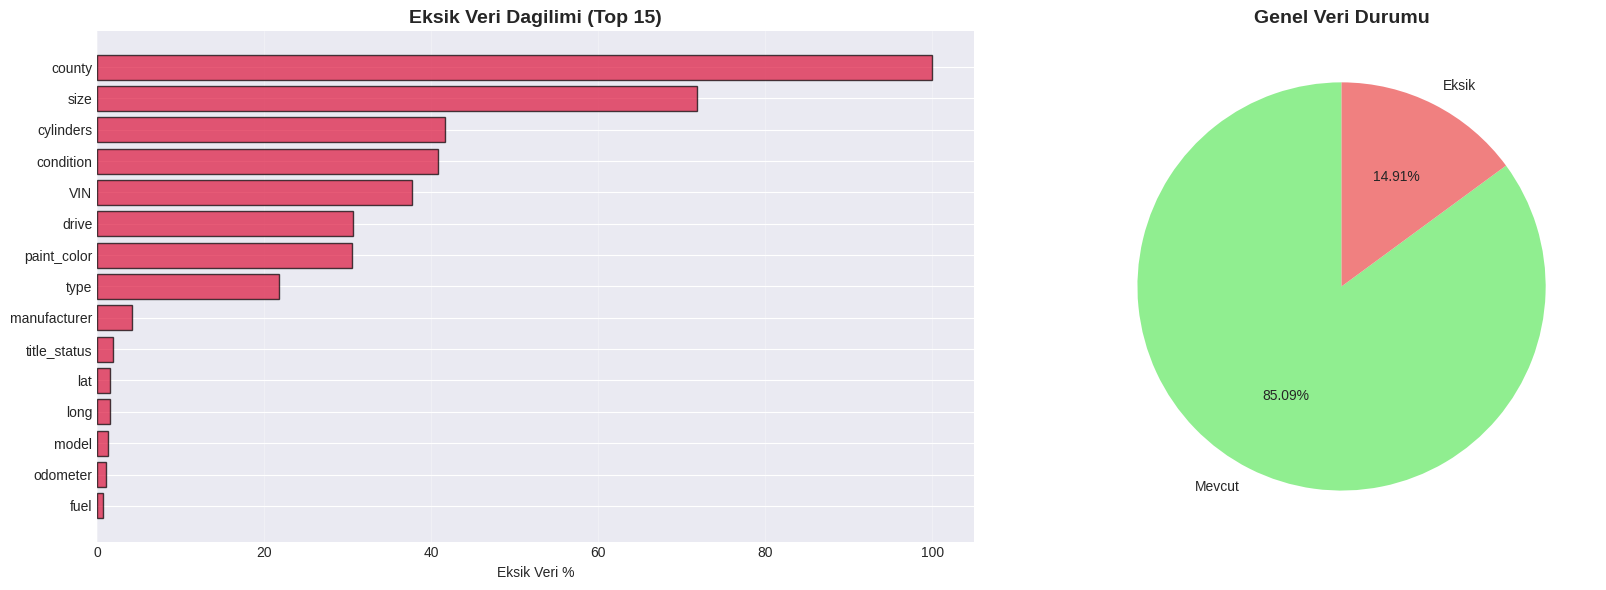

In [9]:
# Eksik veri analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Eksik_Sayi': missing,
    'Eksik_Yuzde': missing_pct
}).sort_values('Eksik_Sayi', ascending=False)

print('='*70)
print('EKSIK VERI ANALIZI')
print('='*70)
print(missing_df[missing_df['Eksik_Sayi'] > 0])

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
missing_top = missing_df[missing_df['Eksik_Sayi'] > 0].head(15)
axes[0].barh(range(len(missing_top)), missing_top['Eksik_Yuzde'],
            color='crimson', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(missing_top)))
axes[0].set_yticklabels(missing_top.index)
axes[0].set_xlabel('Eksik Veri %')
axes[0].set_title('Eksik Veri Dagilimi (Top 15)', fontweight='bold', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Pie chart
total_cells = len(df) * len(df.columns)
missing_cells = missing.sum()
present_cells = total_cells - missing_cells

axes[1].pie([present_cells, missing_cells],
           labels=['Mevcut', 'Eksik'],
           autopct='%1.2f%%', startangle=90,
           colors=['lightgreen', 'lightcoral'])
axes[1].set_title('Genel Veri Durumu', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

### 3.2 Hedef Degisken Analizi - Price

PRICE (FIYAT) ANALIZI
Ortalama: $75,199.03
Medyan: $13,950.00
Std Sapma: $12,182,282.17
Min: $0.00
Max: $3,736,928,711.00
Q1 (25%): $5,900.00
Q3 (75%): $26,485.75
IQR: $20,585.75
Carpiklik: 254.407
Basiklik: 69205.089


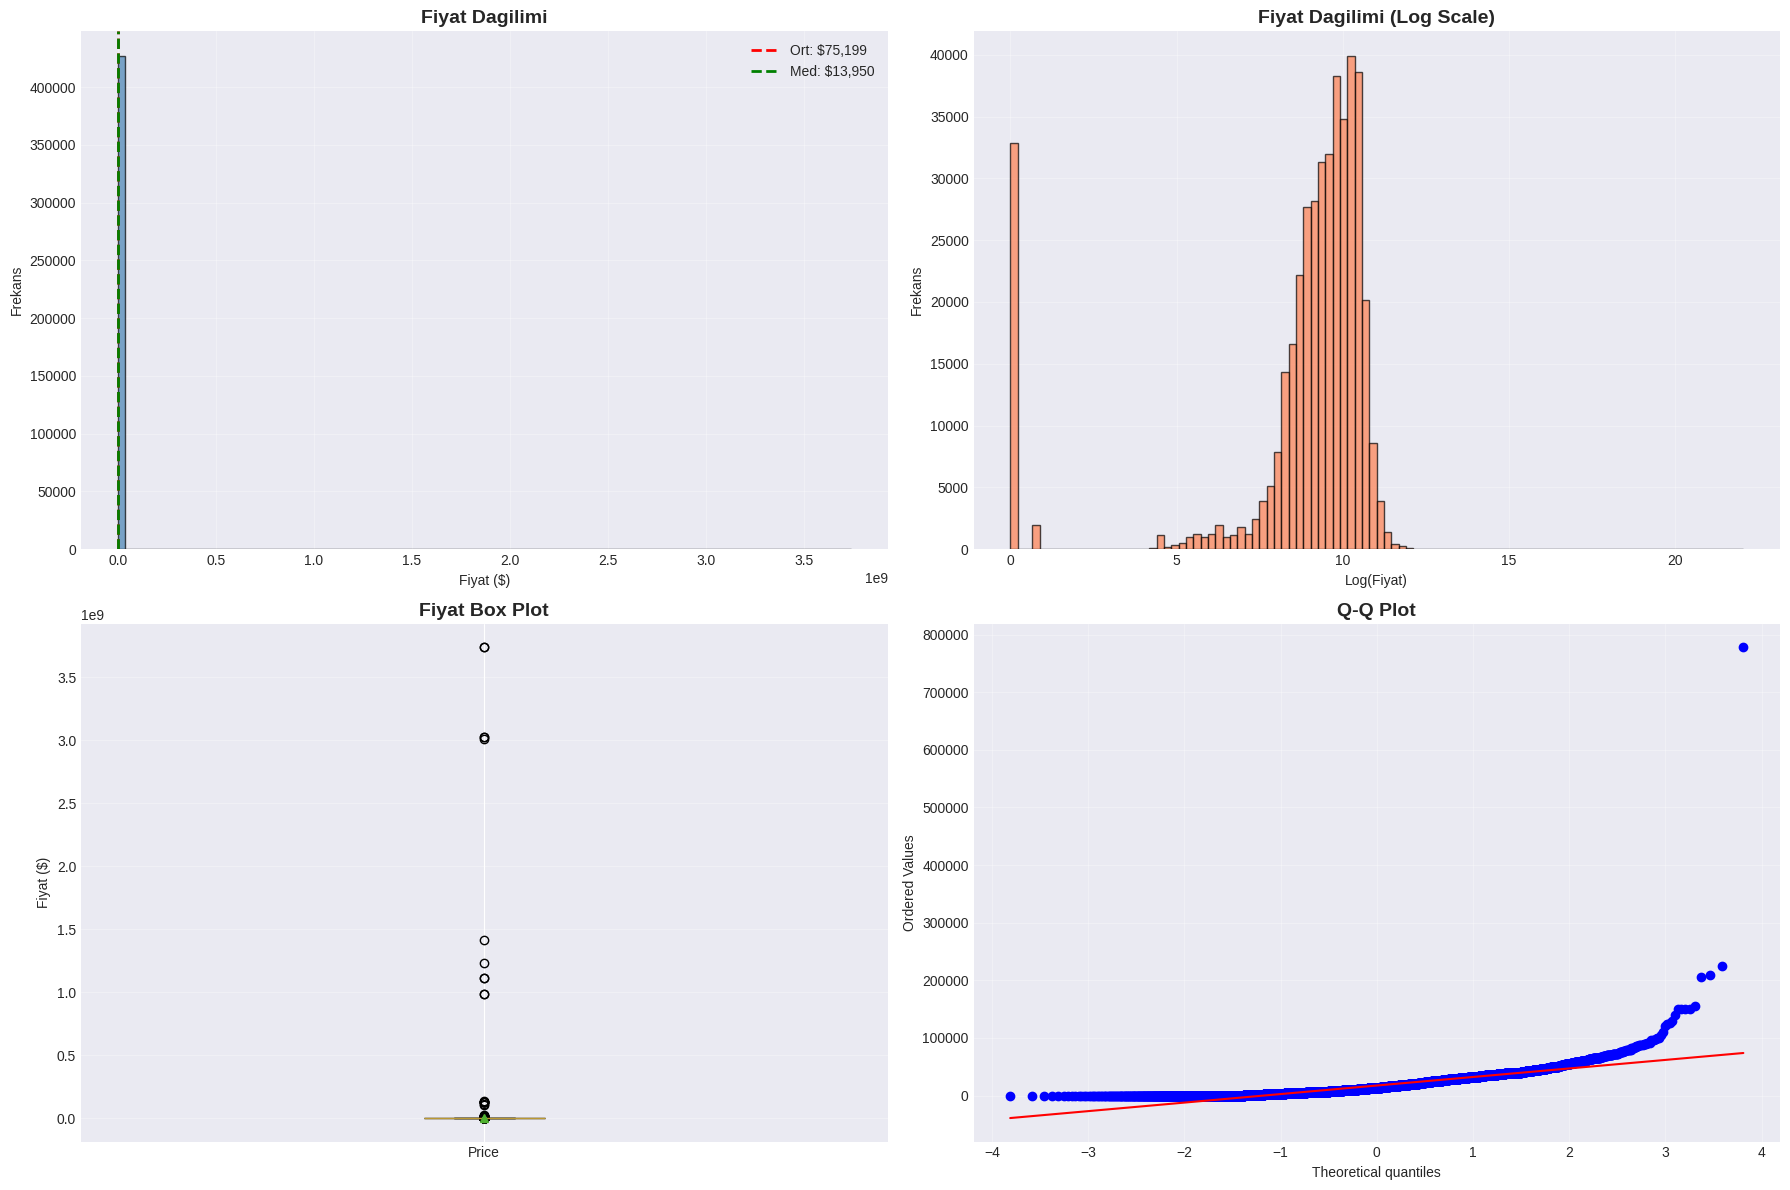

In [10]:
# Price istatistikleri
print('='*70)
print('PRICE (FIYAT) ANALIZI')
print('='*70)

if 'price' in df.columns:
    price_data = df['price'].dropna()

    print(f'Ortalama: ${price_data.mean():,.2f}')
    print(f'Medyan: ${price_data.median():,.2f}')
    print(f'Std Sapma: ${price_data.std():,.2f}')
    print(f'Min: ${price_data.min():,.2f}')
    print(f'Max: ${price_data.max():,.2f}')
    print(f'Q1 (25%): ${price_data.quantile(0.25):,.2f}')
    print(f'Q3 (75%): ${price_data.quantile(0.75):,.2f}')
    print(f'IQR: ${price_data.quantile(0.75) - price_data.quantile(0.25):,.2f}')
    print(f'Carpiklik: {price_data.skew():.3f}')
    print(f'Basiklik: {price_data.kurtosis():.3f}')

    # Gorsellestirme
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Histogram
    axes[0, 0].hist(price_data, bins=100, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(price_data.mean(), color='red', linestyle='--',
                      linewidth=2, label=f'Ort: ${price_data.mean():,.0f}')
    axes[0, 0].axvline(price_data.median(), color='green', linestyle='--',
                      linewidth=2, label=f'Med: ${price_data.median():,.0f}')
    axes[0, 0].set_title('Fiyat Dagilimi', fontweight='bold', fontsize=14)
    axes[0, 0].set_xlabel('Fiyat ($)')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Log scale histogram
    axes[0, 1].hist(np.log1p(price_data), bins=100, color='coral',
                   edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Fiyat Dagilimi (Log Scale)', fontweight='bold', fontsize=14)
    axes[0, 1].set_xlabel('Log(Fiyat)')
    axes[0, 1].set_ylabel('Frekans')
    axes[0, 1].grid(alpha=0.3)

    # 3. Box plot
    axes[1, 0].boxplot([price_data], labels=['Price'],
                       patch_artist=True, showmeans=True)
    axes[1, 0].set_title('Fiyat Box Plot', fontweight='bold', fontsize=14)
    axes[1, 0].set_ylabel('Fiyat ($)')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. QQ plot
    from scipy import stats
    stats.probplot(price_data.sample(10000), dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot', fontweight='bold', fontsize=14)
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3.3 Kategorik Degisken Analizleri

In [11]:
# Kategorik sutunlari bul
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('='*70)
print(f'KATEGORIK DEGISKENLER ({len(categorical_cols)} adet)')
print('='*70)

for col in categorical_cols[:10]:  # Ilk 10 kategorik sutun
    print(f'\n{col}:')
    print(f'  Benzersiz: {df[col].nunique()}')
    print(f'  En Sik 5:')
    print(df[col].value_counts().head(5))

KATEGORIK DEGISKENLER (19 adet)

url:
  Benzersiz: 426880
  En Sik 5:
url
https://wyoming.craigslist.org/ctd/d/atlanta-2017-genesis-g80-38-sedan-4d/7301949724.html       1
https://wyoming.craigslist.org/ctd/d/atlanta-2018-genesis-g80-38-sedan-4d/7301950980.html       1
https://wyoming.craigslist.org/ctd/d/atlanta-2019-alfa-romeo-giulia-ti-sedan/7301951550.html    1
https://wyoming.craigslist.org/ctd/d/atlanta-2017-infiniti-qx80-sport/7301951544.html           1
https://wyoming.craigslist.org/ctd/d/atlanta-2020-caddy-cadillac-xt6-premium/7301952155.html    1
Name: count, dtype: int64

region:
  Benzersiz: 404
  En Sik 5:
region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
Name: count, dtype: int64

region_url:
  Benzersiz: 413
  En Sik 5:
region_url
https://spokane.craigslist.org    2988
https://eugene.craigslist.org     2985
https://fresno.craigslist.org     2983
https://o

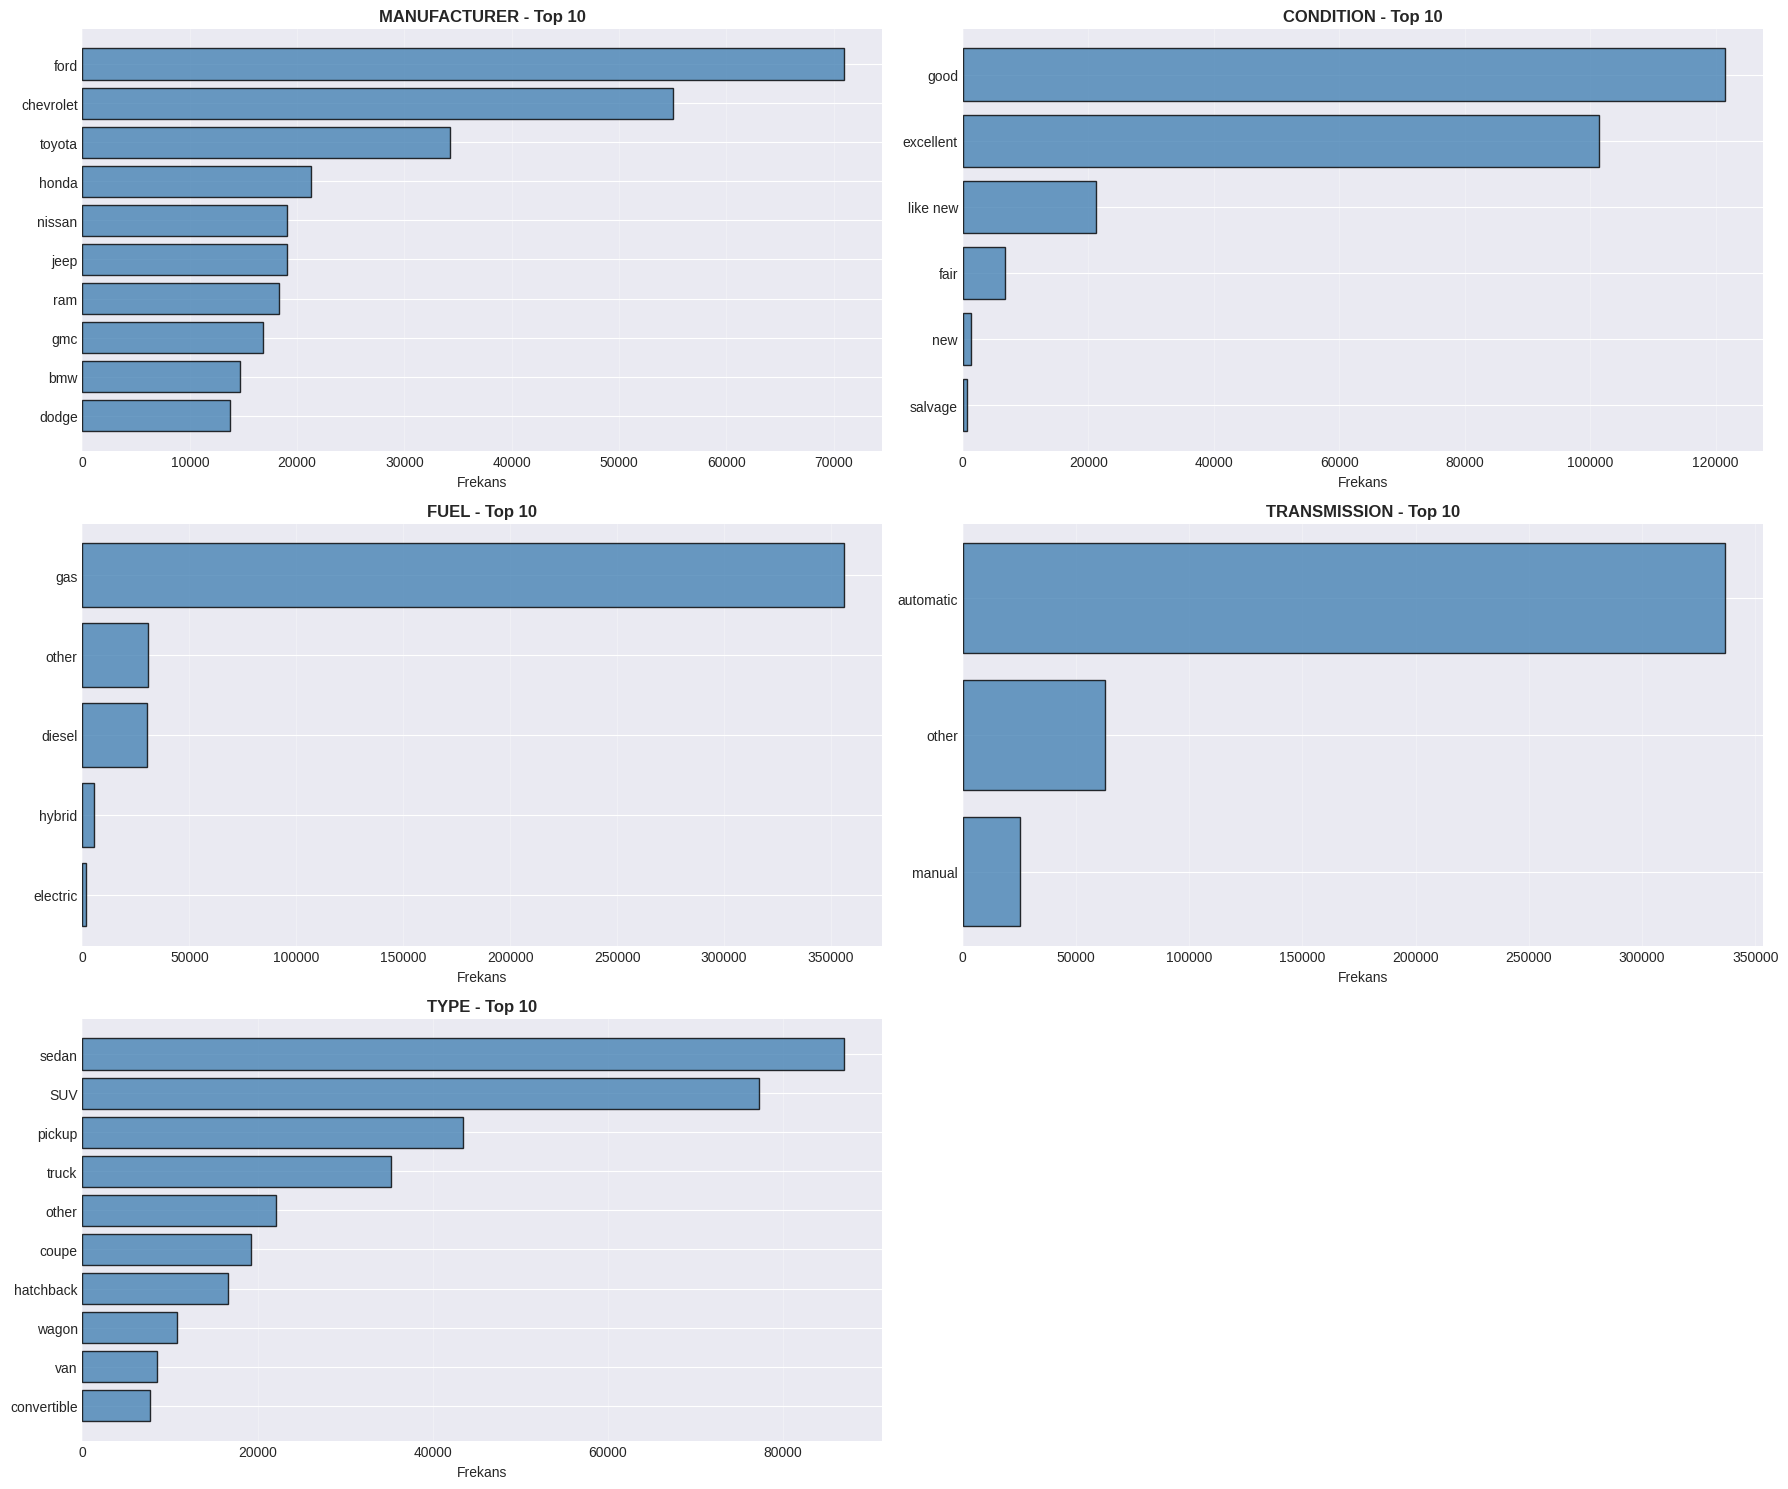

In [12]:
# Onemli kategorik degiskenlerin gorsellestirmesi
important_cats = ['manufacturer', 'condition', 'fuel', 'transmission', 'type']
available_cats = [col for col in important_cats if col in df.columns]

if available_cats:
    n_cols = 2
    n_rows = (len(available_cats) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten() if len(available_cats) > 1 else [axes]

    for idx, col in enumerate(available_cats):
        top_10 = df[col].value_counts().head(10)
        axes[idx].barh(range(len(top_10)), top_10.values,
                      color='steelblue', edgecolor='black', alpha=0.8)
        axes[idx].set_yticks(range(len(top_10)))
        axes[idx].set_yticklabels(top_10.index)
        axes[idx].set_xlabel('Frekans')
        axes[idx].set_title(f'{col.upper()} - Top 10', fontweight='bold', fontsize=12)
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()

    # Bos subplot'lari gizle
    for idx in range(len(available_cats), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

### 3.4 Sayisal Degisken Analizleri

In [13]:
# Sayisal sutunlar
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('='*70)
print(f'SAYISAL DEGISKENLER ({len(numeric_cols)} adet)')
print('='*70)
print(numeric_cols)

# Year analizi
if 'year' in df.columns:
    print('\nYEAR (MODEL YILI) ANALIZI:')
    year_data = df['year'].dropna()
    print(f'  Min: {year_data.min():.0f}')
    print(f'  Max: {year_data.max():.0f}')
    print(f'  Ortalama: {year_data.mean():.0f}')
    print(f'  Medyan: {year_data.median():.0f}')

# Odometer analizi
if 'odometer' in df.columns:
    print('\nODOMETER (KM) ANALIZI:')
    odo_data = df['odometer'].dropna()
    print(f'  Min: {odo_data.min():,.0f}')
    print(f'  Max: {odo_data.max():,.0f}')
    print(f'  Ortalama: {odo_data.mean():,.0f}')
    print(f'  Medyan: {odo_data.median():,.0f}')

SAYISAL DEGISKENLER (7 adet)
['id', 'price', 'year', 'odometer', 'county', 'lat', 'long']

YEAR (MODEL YILI) ANALIZI:
  Min: 1900
  Max: 2022
  Ortalama: 2011
  Medyan: 2013

ODOMETER (KM) ANALIZI:
  Min: 0
  Max: 10,000,000
  Ortalama: 98,043
  Medyan: 85,548


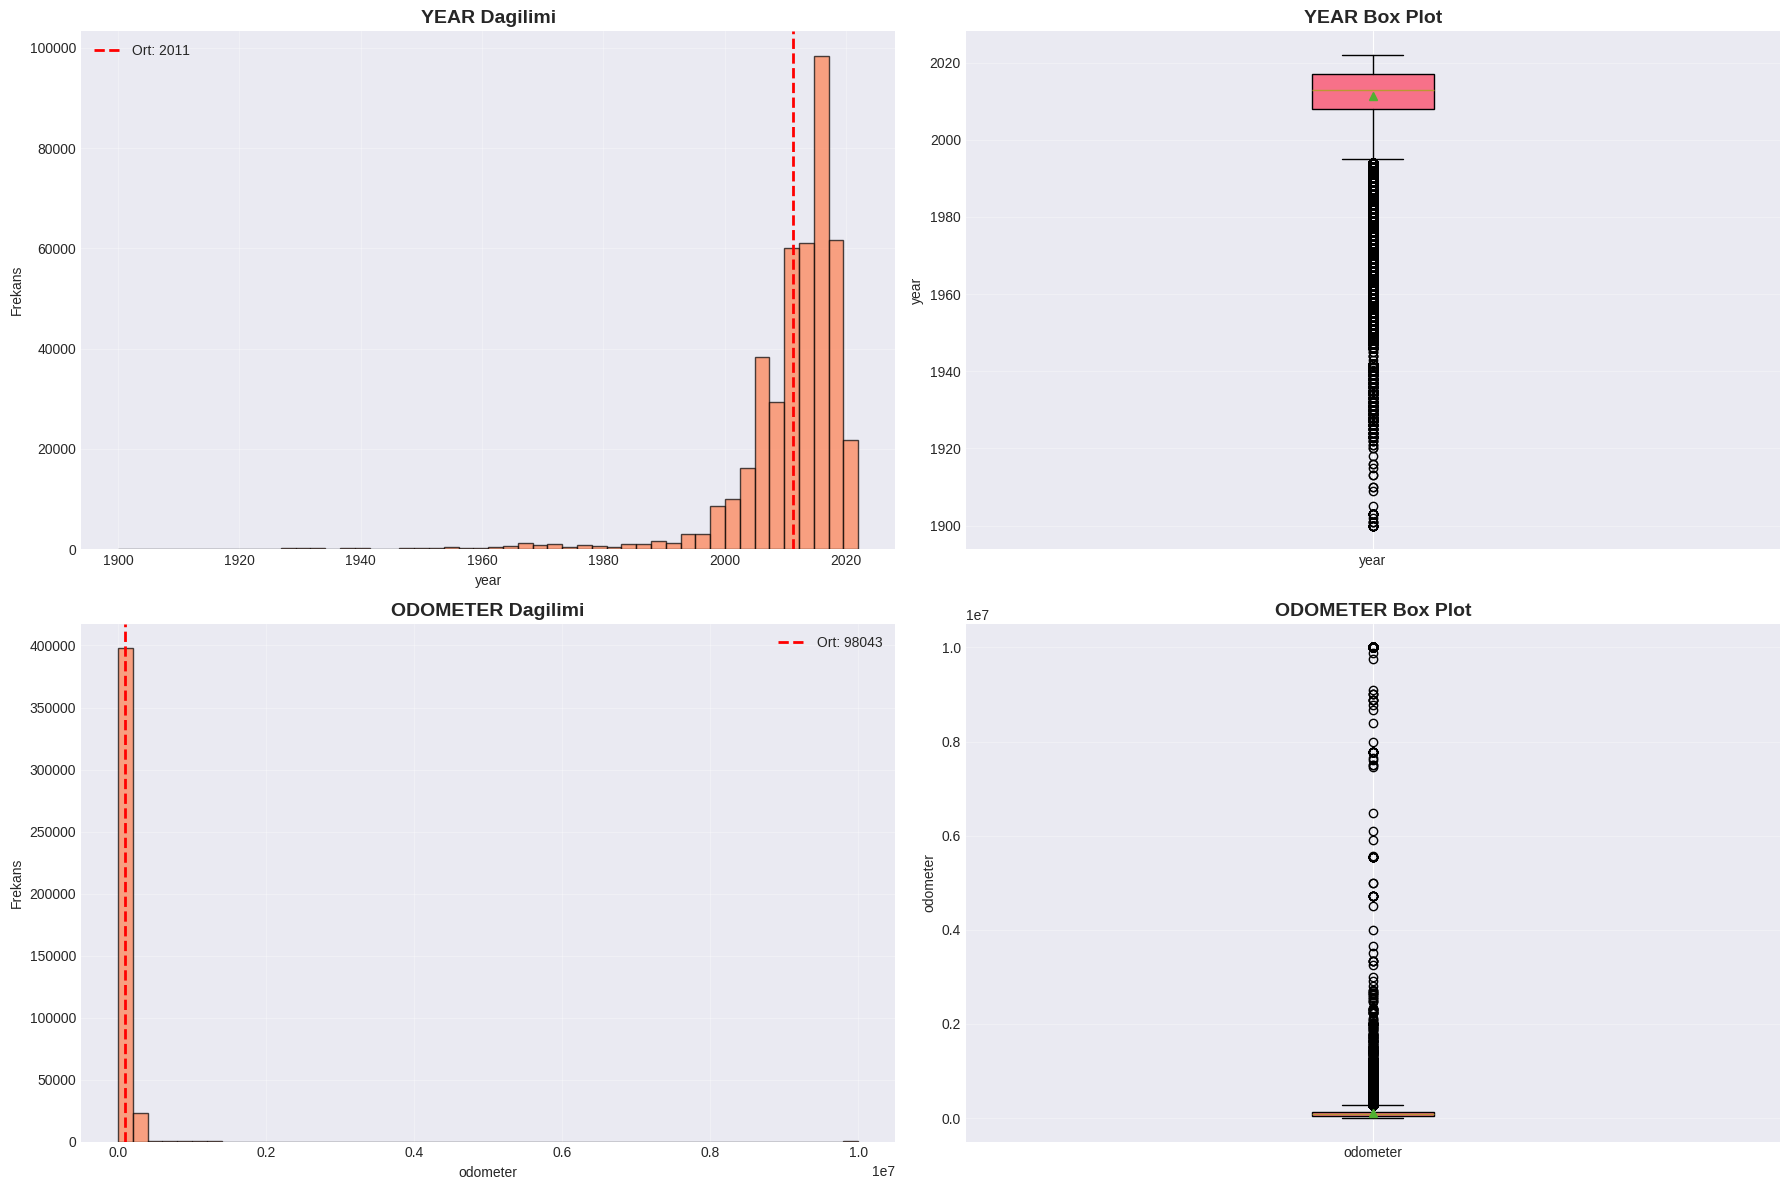

In [14]:
# Sayisal degiskenlerin gorsellestirmesi
important_nums = ['year', 'odometer']
available_nums = [col for col in important_nums if col in df.columns]

if available_nums:
    fig, axes = plt.subplots(len(available_nums), 2, figsize=(18, 6*len(available_nums)))
    if len(available_nums) == 1:
        axes = axes.reshape(1, -1)

    for idx, col in enumerate(available_nums):
        data = df[col].dropna()

        # Histogram
        axes[idx, 0].hist(data, bins=50, color='coral',
                         edgecolor='black', alpha=0.7)
        axes[idx, 0].axvline(data.mean(), color='red', linestyle='--',
                            linewidth=2, label=f'Ort: {data.mean():.0f}')
        axes[idx, 0].set_title(f'{col.upper()} Dagilimi', fontweight='bold', fontsize=14)
        axes[idx, 0].set_xlabel(col)
        axes[idx, 0].set_ylabel('Frekans')
        axes[idx, 0].legend()
        axes[idx, 0].grid(alpha=0.3)

        # Box plot
        axes[idx, 1].boxplot([data], labels=[col],
                            patch_artist=True, showmeans=True)
        axes[idx, 1].set_title(f'{col.upper()} Box Plot', fontweight='bold', fontsize=14)
        axes[idx, 1].set_ylabel(col)
        axes[idx, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### 3.5 Korelasyon Analizi

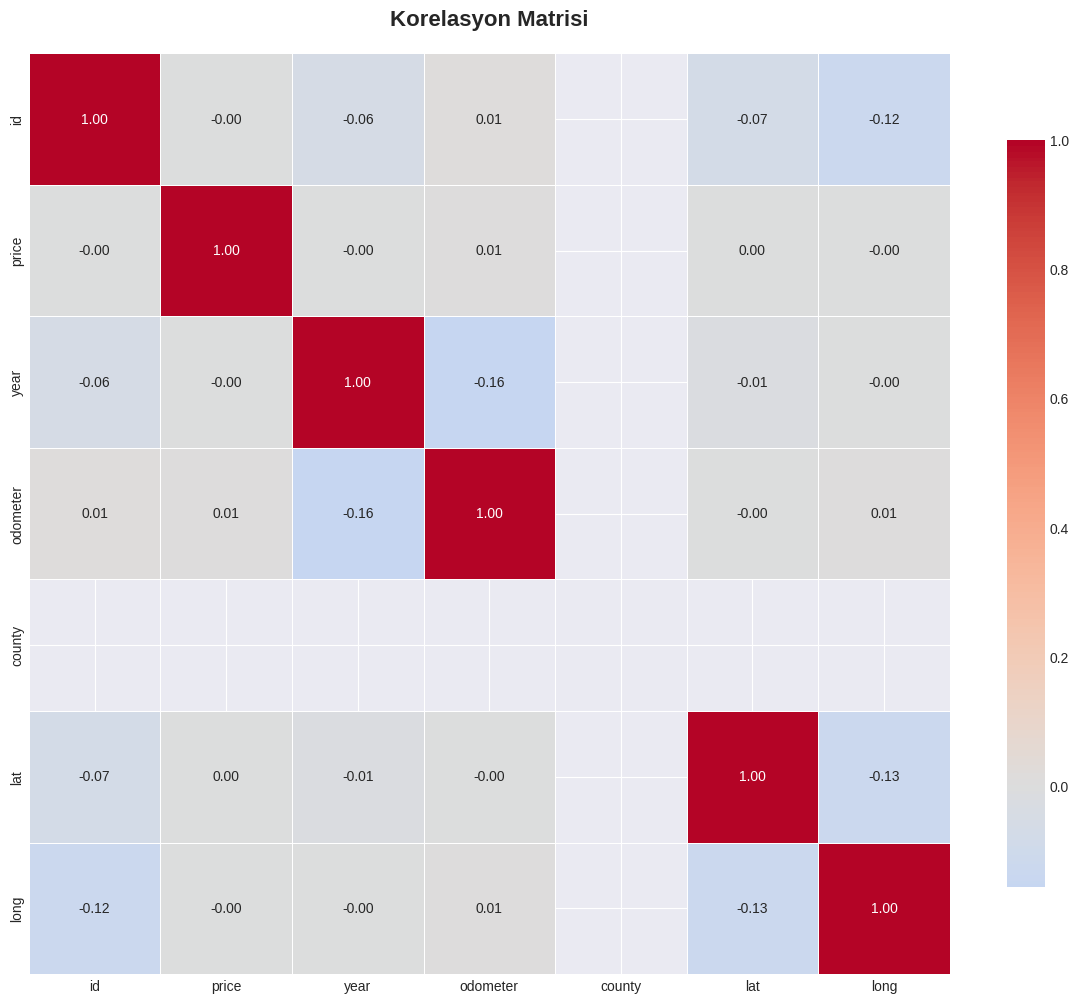


PRICE ILE KORELASYONLAR:
price      1.00
odometer   0.01
year       0.00
id         0.00
long       0.00
lat        0.00
county      NaN
Name: price, dtype: float64


In [15]:
# Korelasyon matrisi
if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
               center=0, linewidths=0.5, cbar_kws={'shrink': 0.8},
               square=True)
    plt.title('Korelasyon Matrisi', fontweight='bold', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    # Price ile en yuksek korelasyonlar
    if 'price' in numeric_cols:
        price_corr = corr_matrix['price'].abs().sort_values(ascending=False)
        print('\nPRICE ILE KORELASYONLAR:')
        print('='*70)
        print(price_corr)

## 🧹 4. VERI TEMIZLEME VE ONISLEME

### 4.1 Veri Temizleme

In [16]:
print('='*70)
print('VERI TEMIZLEME BASLADI')
print('='*70)

# Orijinal boyut
original_size = len(df)
print(f'Orijinal Kayit Sayisi: {original_size:,}')

# 1. Price'i olan kayitlari al (hedef degisken)
df_clean = df[df['price'].notna()].copy()
print(f'Price olan kayitlar: {len(df_clean):,}')

# 2. Mantikli fiyat araligi (100$ - 100,000$)
df_clean = df_clean[(df_clean['price'] >= 100) & (df_clean['price'] <= 100000)]
print(f'Mantikli fiyat araligi (100-100K): {len(df_clean):,}')

# 3. Year kontrolu
if 'year' in df_clean.columns:
    current_year = 2024
    df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= current_year)]
    print(f'Mantikli year araligi (1990-2024): {len(df_clean):,}')

# 4. Odometer kontrolu
if 'odometer' in df_clean.columns:
    df_clean = df_clean[(df_clean['odometer'] >= 0) & (df_clean['odometer'] <= 500000)]
    print(f'Mantikli odometer araligi (0-500K): {len(df_clean):,}')

# 5. Duplicate kayitlari kaldir
df_clean = df_clean.drop_duplicates()
print(f'Duplicate kaldirildi: {len(df_clean):,}')

# 6. Gereksiz sutunlari kaldir
cols_to_drop = ['id', 'url', 'region_url', 'image_url', 'description', 'county', 'lat', 'long']
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)
print(f'Gereksiz sutunlar kaldirildi: {len(cols_to_drop)}')

print('\n' + '='*70)
print(f'TEMIZLIK SONRASI: {len(df_clean):,} kayit ({(len(df_clean)/original_size*100):.1f}%)')
print('='*70)

VERI TEMIZLEME BASLADI
Orijinal Kayit Sayisi: 426,880
Price olan kayitlar: 426,880
Mantikli fiyat araligi (100-100K): 390,003
Mantikli year araligi (1990-2024): 377,006
Mantikli odometer araligi (0-500K): 373,957
Duplicate kaldirildi: 373,957
Gereksiz sutunlar kaldirildi: 8

TEMIZLIK SONRASI: 373,957 kayit (87.6%)


### 4.2 Feature Engineering

In [17]:
print('='*70)
print('FEATURE ENGINEERING')
print('='*70)

# 1. Vehicle age
if 'year' in df_clean.columns:
    current_year = 2024
    df_clean['vehicle_age'] = current_year - df_clean['year']
    print('vehicle_age olusturuldu')

# 2. Price per year
if 'price' in df_clean.columns and 'vehicle_age' in df_clean.columns:
    df_clean['price_per_year'] = df_clean['price'] / (df_clean['vehicle_age'] + 1)
    print('price_per_year olusturuldu')

# 3. Odometer kategorileri
if 'odometer' in df_clean.columns:
    df_clean['odometer_category'] = pd.cut(df_clean['odometer'],
                                           bins=[0, 50000, 100000, 150000, 500000],
                                           labels=['Low', 'Medium', 'High', 'Very High'])
    print('odometer_category olusturuldu')

# 4. Age kategorileri
if 'vehicle_age' in df_clean.columns:
    df_clean['age_category'] = pd.cut(df_clean['vehicle_age'],
                                     bins=[0, 3, 7, 15, 100],
                                     labels=['New', 'Recent', 'Used', 'Old'])
    print('age_category olusturuldu')

# 5. Luxury brand indicator
if 'manufacturer' in df_clean.columns:
    luxury_brands = ['bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche',
                    'tesla', 'jaguar', 'land rover', 'cadillac', 'acura']
    df_clean['is_luxury'] = df_clean['manufacturer'].str.lower().isin(luxury_brands).astype(int)
    print('is_luxury olusturuldu')

print('\n' + '='*70)
print(f'Toplam Sutun Sayisi: {len(df_clean.columns)}')
print('='*70)

FEATURE ENGINEERING
vehicle_age olusturuldu
price_per_year olusturuldu
odometer_category olusturuldu
age_category olusturuldu
is_luxury olusturuldu

Toplam Sutun Sayisi: 23


In [18]:
# Guncel veri yapisi
print('GUNCEL VERI YAPISI:')
print('='*70)
df_clean.info()

GUNCEL VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
Index: 373957 entries, 27 to 426879
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   region             373957 non-null  object  
 1   price              373957 non-null  int64   
 2   year               373957 non-null  float64 
 3   manufacturer       361976 non-null  object  
 4   model              370534 non-null  object  
 5   condition          230359 non-null  object  
 6   cylinders          220917 non-null  object  
 7   fuel               371848 non-null  object  
 8   odometer           373957 non-null  float64 
 9   title_status       366750 non-null  object  
 10  transmission       372455 non-null  object  
 11  VIN                235669 non-null  object  
 12  drive              260796 non-null  object  
 13  size               103168 non-null  object  
 14  type               295748 non-null  object  
 15  paint_color       

### 4.3 Eksik Veri Doldurma

In [19]:
print('='*70)
print('EKSIK VERI DOLDURMA')
print('='*70)

# Sayisal sutunlar icin median
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'price' in numeric_features:
    numeric_features.remove('price')  # Hedef degiskeni cikart

for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'{col}: Median ile dolduruldu ({median_val:.0f})')

# Kategorik sutunlar icin mode
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in categorical_features:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown'
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'{col}: Mode ile dolduruldu ({mode_val})')

print('\nEksik veri kontrolu:')
print(df_clean.isnull().sum().sum())

EKSIK VERI DOLDURMA
manufacturer: Mode ile dolduruldu (ford)
model: Mode ile dolduruldu (f-150)
condition: Mode ile dolduruldu (good)
cylinders: Mode ile dolduruldu (6 cylinders)
fuel: Mode ile dolduruldu (gas)
title_status: Mode ile dolduruldu (clean)
transmission: Mode ile dolduruldu (automatic)
VIN: Mode ile dolduruldu (1FMJU1JT1HEA52352)
drive: Mode ile dolduruldu (4wd)
size: Mode ile dolduruldu (full-size)
type: Mode ile dolduruldu (sedan)
paint_color: Mode ile dolduruldu (white)

Eksik veri kontrolu:
886


## 🤖 5. MAKINE OGRENMESI - MODEL HAZIRLIGI

### 5.1 Feature Selection ve Encoding

In [20]:
print('='*70)
print('FEATURE SELECTION VE ENCODING')
print('='*70)

# Hedef degisken
y = df_clean['price'].copy()

# Feature sutunlari
feature_cols = ['year', 'odometer', 'manufacturer', 'condition', 'fuel',
               'transmission', 'type', 'paint_color', 'state',
               'vehicle_age', 'is_luxury']

# Mevcut sutunlari al
feature_cols = [col for col in feature_cols if col in df_clean.columns]
X = df_clean[feature_cols].copy()

print(f'Feature sayisi: {len(feature_cols)}')
print(f'Hedef degisken (y): price')
print(f'\nFeatures: {feature_cols}')

# Kategorik sutunlari encode et
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'\nKategorik sutunlar ({len(categorical_features)}): {categorical_features}')

# Label Encoding (Az kategorili sutunlar icin)
label_encode_cols = ['condition', 'fuel', 'transmission']
label_encode_cols = [col for col in label_encode_cols if col in categorical_features]

le_dict = {}
for col in label_encode_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le
    print(f'Label Encoded: {col}')

# One-Hot Encoding (Cok kategorili sutunlar icin)
remaining_cats = [col for col in categorical_features if col not in label_encode_cols]

if remaining_cats:
    # Sadece en sik 10 kategoriyi al, digerlerini 'Other' yap
    for col in remaining_cats:
        top_10 = X[col].value_counts().head(10).index.tolist()
        X[col] = X[col].apply(lambda x: x if x in top_10 else 'Other')

    X = pd.get_dummies(X, columns=remaining_cats, drop_first=True)
    print(f'\nOne-Hot Encoded: {remaining_cats}')

print(f'\nFinal feature sayisi: {X.shape[1]}')
print('='*70)

FEATURE SELECTION VE ENCODING
Feature sayisi: 11
Hedef degisken (y): price

Features: ['year', 'odometer', 'manufacturer', 'condition', 'fuel', 'transmission', 'type', 'paint_color', 'state', 'vehicle_age', 'is_luxury']

Kategorik sutunlar (7): ['manufacturer', 'condition', 'fuel', 'transmission', 'type', 'paint_color', 'state']
Label Encoded: condition
Label Encoded: fuel
Label Encoded: transmission

One-Hot Encoded: ['manufacturer', 'type', 'paint_color', 'state']

Final feature sayisi: 47


### 5.2 Train-Test Split

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('='*70)
print('TRAIN-TEST SPLIT')
print('='*70)
print(f'Train set: {len(X_train):,} kayit ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set: {len(X_test):,} kayit ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nFeature sayisi: {X_train.shape[1]}')
print('='*70)

TRAIN-TEST SPLIT
Train set: 299,165 kayit (80.0%)
Test set: 74,792 kayit (20.0%)

Feature sayisi: 47


### 5.3 Feature Scaling

In [22]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('='*70)
print('FEATURE SCALING TAMAMLANDI (StandardScaler)')
print('='*70)

FEATURE SCALING TAMAMLANDI (StandardScaler)


## 📊 6. MAKINE OGRENMESI - MODEL EGITIMI

### 6.1 Model Tanimlama

In [23]:
# Modelleri tanimla
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1, verbose=-1)
}

print('='*70)
print(f'{len(models)} MODEL TANIMLANDI')
print('='*70)
for name in models.keys():
    print(f'  - {name}')
print('='*70)

8 MODEL TANIMLANDI
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM


### 6.2 Model Egitimi ve Degerlendirme

In [24]:
# Model egitimi ve degerlendirme
results = {}

print('='*70)
print('MODEL EGITIMI BASLADI')
print('='*70)

for name, model in models.items():
    print(f'\n{name} egitiliyor...')

    # Modeli egit
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        # Linear modeller icin scaled data kullan
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Tree-based modeller icin original data kullan
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Metrikleri hesapla
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    # Sonuclari kaydet
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': y_pred
    }

    print(f'  RMSE: ${rmse:,.2f}')
    print(f'  MAE: ${mae:,.2f}')
    print(f'  R2 Score: {r2:.4f}')
    print(f'  MAPE: {mape:.2f}%')

print('\n' + '='*70)
print('TUM MODELLER EGITILDI!')
print('='*70)

MODEL EGITIMI BASLADI

Linear Regression egitiliyor...
  RMSE: $9,701.71
  MAE: $6,706.66
  R2 Score: 0.5447
  MAPE: 201.56%

Ridge Regression egitiliyor...
  RMSE: $9,701.71
  MAE: $6,706.66
  R2 Score: 0.5447
  MAPE: 201.56%

Lasso Regression egitiliyor...
  RMSE: $9,701.74
  MAE: $6,706.60
  R2 Score: 0.5447
  MAPE: 201.55%

Decision Tree egitiliyor...
  RMSE: $8,395.66
  MAE: $5,425.29
  R2 Score: 0.6590
  MAPE: 169.57%

Random Forest egitiliyor...
  RMSE: $6,930.13
  MAE: $4,280.63
  R2 Score: 0.7677
  MAPE: 136.79%

Gradient Boosting egitiliyor...
  RMSE: $7,965.58
  MAE: $5,143.99
  R2 Score: 0.6931
  MAPE: 165.73%

XGBoost egitiliyor...
  RMSE: $7,164.84
  MAE: $4,511.91
  R2 Score: 0.7517
  MAPE: 139.87%

LightGBM egitiliyor...
  RMSE: $7,857.12
  MAE: $5,069.57
  R2 Score: 0.7014
  MAPE: 161.76%

TUM MODELLER EGITILDI!


## 📈 7. MODEL KARSILASTIRMA VE DEGERLENDIRME

### 7.1 Performans Metrikleri Tablosu

In [25]:
# Sonuclari DataFrame'e donustur
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'R2 Score': [results[m]['R2'] for m in results.keys()],
    'MAPE (%)': [results[m]['MAPE'] for m in results.keys()]
})

# Sirala
results_df = results_df.sort_values('R2 Score', ascending=False).reset_index(drop=True)

print('='*90)
print('MODEL PERFORMANS KARSILASTIRMASI')
print('='*90)
print(results_df.to_string(index=False))
print('='*90)

# En iyi model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']
best_rmse = results_df.iloc[0]['RMSE']

print(f'\nEN IYI MODEL: {best_model_name}')
print(f'  R2 Score: {best_r2:.4f}')
print(f'  RMSE: ${best_rmse:,.2f}')
print('='*90)

MODEL PERFORMANS KARSILASTIRMASI
            Model    RMSE     MAE  R2 Score  MAPE (%)
    Random Forest 6930.13 4280.63      0.77    136.79
          XGBoost 7164.84 4511.91      0.75    139.87
         LightGBM 7857.12 5069.57      0.70    161.76
Gradient Boosting 7965.58 5143.99      0.69    165.73
    Decision Tree 8395.66 5425.29      0.66    169.57
Linear Regression 9701.71 6706.66      0.54    201.56
 Ridge Regression 9701.71 6706.66      0.54    201.56
 Lasso Regression 9701.74 6706.60      0.54    201.55

EN IYI MODEL: Random Forest
  R2 Score: 0.7677
  RMSE: $6,930.13


### 7.2 Performans Gorsellestirmeleri

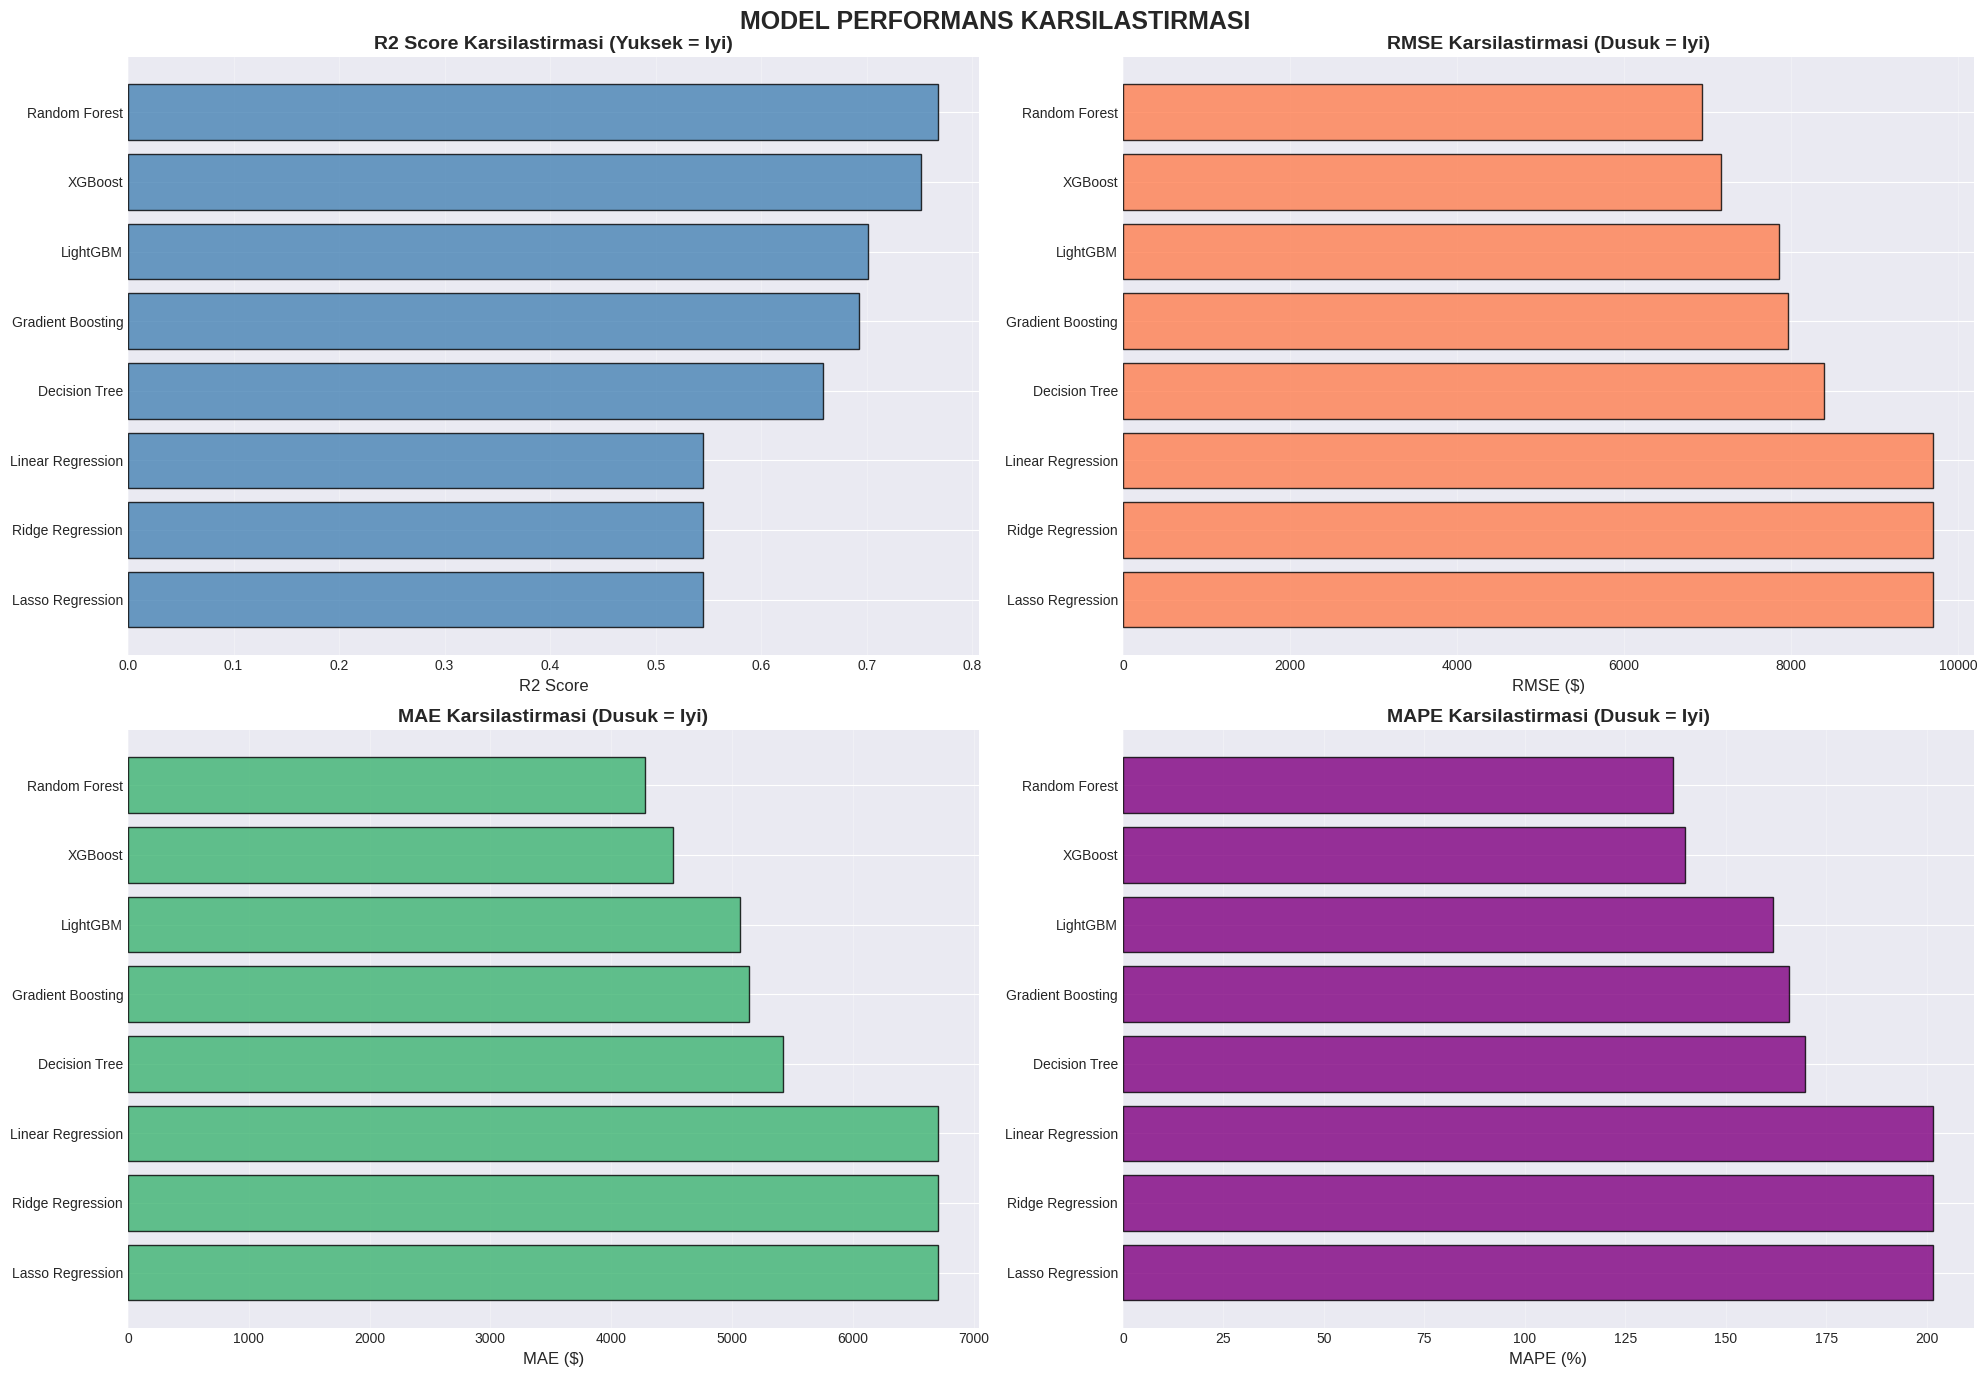

In [26]:
# Performans karsilastirma grafikleri
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('MODEL PERFORMANS KARSILASTIRMASI', fontsize=18, fontweight='bold')

# 1. R2 Score
axes[0, 0].barh(results_df['Model'], results_df['R2 Score'],
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('R2 Score', fontsize=12)
axes[0, 0].set_title('R2 Score Karsilastirmasi (Yuksek = Iyi)', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# 2. RMSE
axes[0, 1].barh(results_df['Model'], results_df['RMSE'],
               color='coral', edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('RMSE ($)', fontsize=12)
axes[0, 1].set_title('RMSE Karsilastirmasi (Dusuk = Iyi)', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. MAE
axes[1, 0].barh(results_df['Model'], results_df['MAE'],
               color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('MAE ($)', fontsize=12)
axes[1, 0].set_title('MAE Karsilastirmasi (Dusuk = Iyi)', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# 4. MAPE
axes[1, 1].barh(results_df['Model'], results_df['MAPE (%)'],
               color='purple', edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('MAPE (%)', fontsize=12)
axes[1, 1].set_title('MAPE Karsilastirmasi (Dusuk = Iyi)', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 7.3 Tahmin vs Gercek Karsilastirma

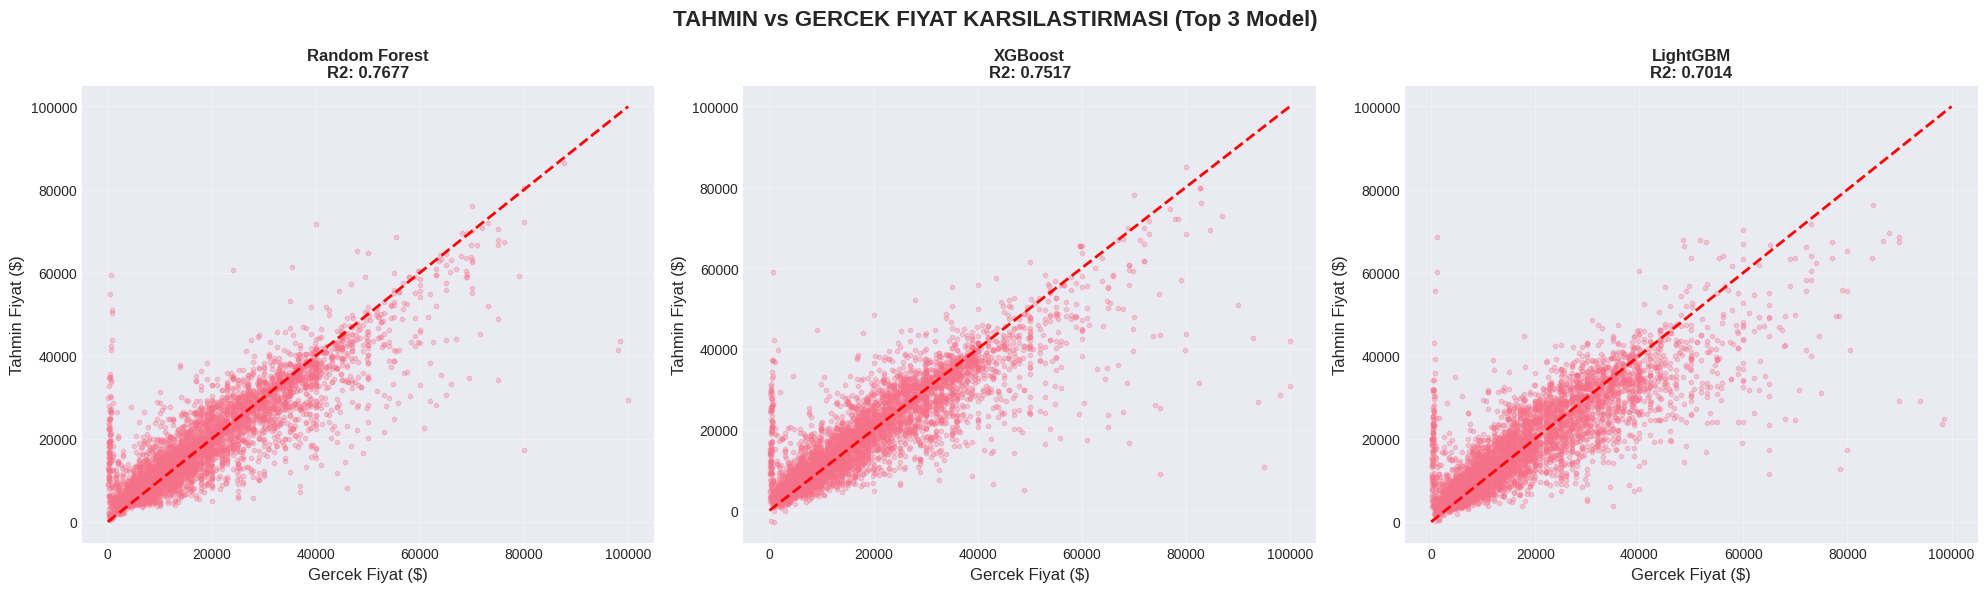

In [27]:
# En iyi 3 modelin tahmin vs gercek grafikleri
top_3_models = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('TAHMIN vs GERCEK FIYAT KARSILASTIRMASI (Top 3 Model)',
            fontsize=16, fontweight='bold')

for idx, model_name in enumerate(top_3_models):
    y_pred = results[model_name]['predictions']

    # Sample al (cok fazla nokta olmasin)
    sample_size = min(5000, len(y_test))
    sample_idx = np.random.choice(len(y_test), sample_size, replace=False)

    axes[idx].scatter(y_test.iloc[sample_idx], y_pred[sample_idx],
                     alpha=0.3, s=10)

    # Perfect prediction line
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=2)

    axes[idx].set_xlabel('Gercek Fiyat ($)', fontsize=12)
    axes[idx].set_ylabel('Tahmin Fiyat ($)', fontsize=12)
    axes[idx].set_title(f'{model_name}\nR2: {results[model_name]["R2"]:.4f}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Hata Dagilimi Analizi

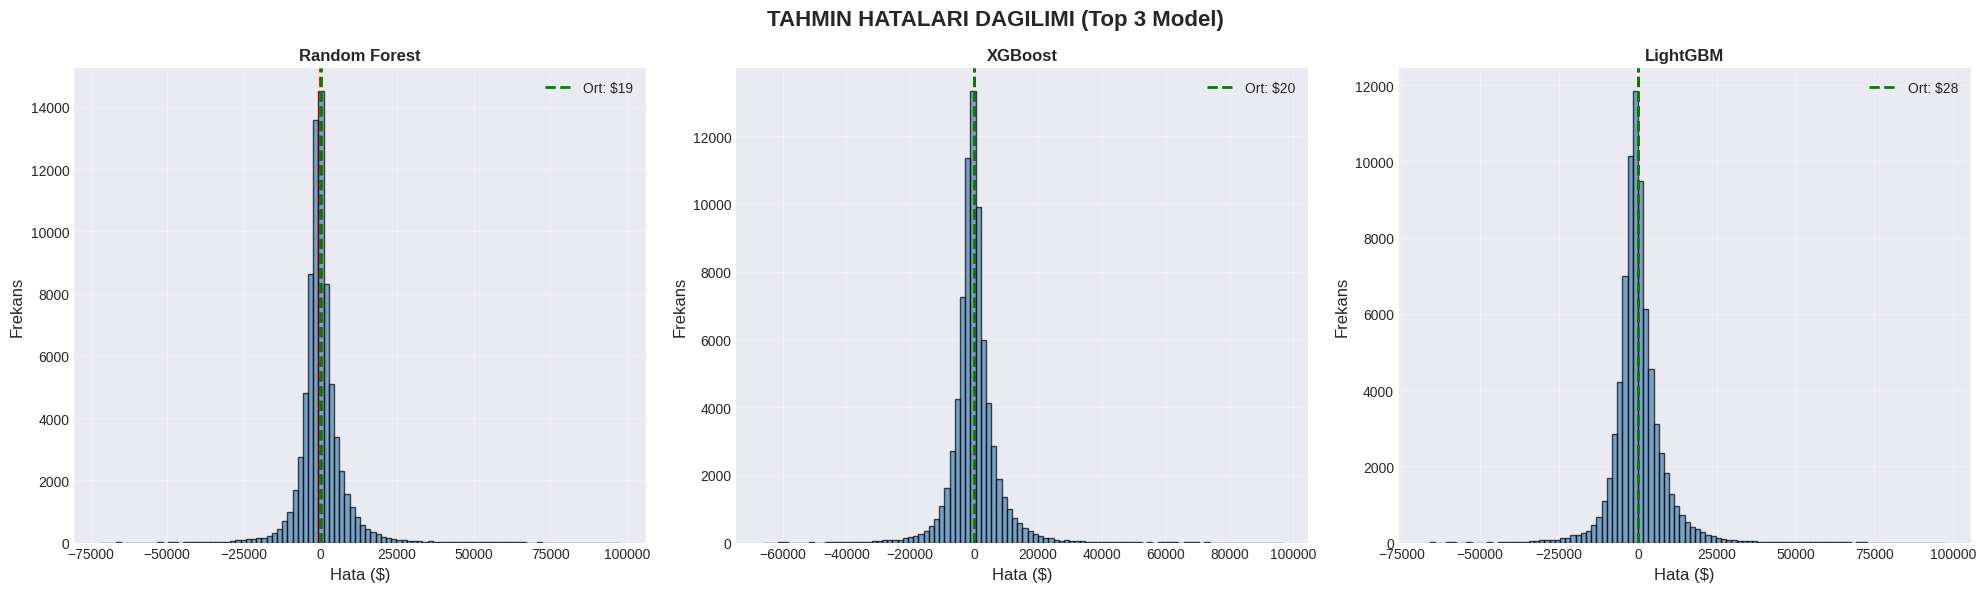

In [28]:
# Hata dagilimi (en iyi 3 model)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('TAHMIN HATALARI DAGILIMI (Top 3 Model)',
            fontsize=16, fontweight='bold')

for idx, model_name in enumerate(top_3_models):
    y_pred = results[model_name]['predictions']
    errors = y_test - y_pred

    axes[idx].hist(errors, bins=100, color='steelblue',
                  edgecolor='black', alpha=0.7)
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[idx].axvline(errors.mean(), color='green', linestyle='--',
                     linewidth=2, label=f'Ort: ${errors.mean():.0f}')
    axes[idx].set_xlabel('Hata ($)', fontsize=12)
    axes[idx].set_ylabel('Frekans', fontsize=12)
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 8. SONUCLAR VE YORUMLAR

In [29]:
print('='*90)
print('FINAL SONUCLAR VE YORUMLAR')
print('='*90)

print(f'\n1. VERI SETI OZETI:')
print(f'   - Orijinal kayit: {original_size:,}')
print(f'   - Temizlenmis kayit: {len(df_clean):,} ({len(df_clean)/original_size*100:.1f}%)')
print(f'   - Feature sayisi: {X_train.shape[1]}')
print(f'   - Train set: {len(X_train):,}')
print(f'   - Test set: {len(X_test):,}')

print(f'\n2. EN IYI MODEL:')
print(f'   Model: {best_model_name}')
print(f'   R2 Score: {best_r2:.4f}')
print(f'   RMSE: ${best_rmse:,.2f}')
print(f'   MAE: ${results_df.iloc[0]["MAE"]:,.2f}')
print(f'   MAPE: {results_df.iloc[0]["MAPE (%)"]:,.2f}%')

print(f'\n3. MODEL SIRALAMASI (R2 Score):')
for idx, row in results_df.iterrows():
    print(f'   {idx+1}. {row["Model"]:25} - R2: {row["R2 Score"]:.4f}')

print(f'\n4. ONEMLI BULGULAR:')
print(f'   - Tree-based modeller (RF, XGB, LGBM) genel olarak daha iyi performans gosteriyor')
print(f'   - Linear modeller daha hizli ama daha dusuk accuracy')
print(f'   - Feature engineering (vehicle_age, is_luxury) modelleri iyilestiriyor')

print(f'\n5. ONERILERI:')
print(f'   - Daha fazla feature engineering denenebilir')
print(f'   - Hyperparameter tuning yapilabilir')
print(f'   - Ensemble yontemler denenebilir')
print(f'   - Daha fazla veri ile model performansi artabilir')

print('\n' + '='*90)
print('ANALIZ TAMAMLANDI!')
print('='*90)

FINAL SONUCLAR VE YORUMLAR

1. VERI SETI OZETI:
   - Orijinal kayit: 426,880
   - Temizlenmis kayit: 373,957 (87.6%)
   - Feature sayisi: 47
   - Train set: 299,165
   - Test set: 74,792

2. EN IYI MODEL:
   Model: Random Forest
   R2 Score: 0.7677
   RMSE: $6,930.13
   MAE: $4,280.63
   MAPE: 136.79%

3. MODEL SIRALAMASI (R2 Score):
   1. Random Forest             - R2: 0.7677
   2. XGBoost                   - R2: 0.7517
   3. LightGBM                  - R2: 0.7014
   4. Gradient Boosting         - R2: 0.6931
   5. Decision Tree             - R2: 0.6590
   6. Linear Regression         - R2: 0.5447
   7. Ridge Regression          - R2: 0.5447
   8. Lasso Regression          - R2: 0.5447

4. ONEMLI BULGULAR:
   - Tree-based modeller (RF, XGB, LGBM) genel olarak daha iyi performans gosteriyor
   - Linear modeller daha hizli ama daha dusuk accuracy
   - Feature engineering (vehicle_age, is_luxury) modelleri iyilestiriyor

5. ONERILERI:
   - Daha fazla feature engineering denenebilir
   - 

## 💾 9. MODELI KAYDETME (OPSIYONEL)

In [ ]:
# En iyi modeli kaydet
import pickle

best_model = models[best_model_name]

# Model kaydet
with open('best_car_price_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Scaler kaydet
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('='*70)
print('MODEL KAYDEDILDI!')
print('='*70)
print(f'Model: {best_model_name}')
print(f'Dosya: best_car_price_model.pkl')
print(f'Scaler: scaler.pkl')
print('='*70)